Pg3:Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., legal, medical) and analyze how embeddings capture domain-specific semantics.

In [1]:
# Install required libraries
!pip install gensim matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.2 MB/s eta 0:00:00


In [2]:
# Import libraries
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

In [4]:
# Sample domain-specific corpus (medical domain)
medical_corpus = [
"The patient was diagnosed with diabetes and hypertension.",
"MRI scans reveal abnormalities in the brain tissue.",
"The treatment involves antibiotics and regular monitoring.",
"Symptoms include fever, fatigue, and muscle pain.",
"The vaccine is effective against several viral infections.",
"Doctors recommend physical therapy for recovery.",
"The clinical trial results were published in the journal.",
"The surgeon performed a minimally invasive procedure.",
"The prescription includes pain relievers and anti-inflammatory drugs.",
"The diagnosis confirmed a rare genetic disorder."
]

#medical_corpus = [
#"Paramahansa Yogananda was an Indian yogi and guru.",
#"He introduced many Westerners to the methods of meditation and Kriya Yoga through his book Autobiography of a Yogi.",
#"He founded the Self-Realization Fellowship / Yogada Satsang Samaj to spread his teachings."
#]


In [5]:
#Preprocess corpus (tokenize sentences)
#sed to convert all characters in a string to lowercase and then split the resulting string into a list of words based on whitespace
processed_corpus = [sentence.lower().split() for sentence in medical_corpus]
processed_corpus

[['the',
  'patient',
  'was',
  'diagnosed',
  'with',
  'diabetes',
  'and',
  'hypertension.'],
 ['mri', 'scans', 'reveal', 'abnormalities', 'in', 'the', 'brain', 'tissue.'],
 ['the',
  'treatment',
  'involves',
  'antibiotics',
  'and',
  'regular',
  'monitoring.'],
 ['symptoms', 'include', 'fever,', 'fatigue,', 'and', 'muscle', 'pain.'],
 ['the',
  'vaccine',
  'is',
  'effective',
  'against',
  'several',
  'viral',
  'infections.'],
 ['doctors', 'recommend', 'physical', 'therapy', 'for', 'recovery.'],
 ['the',
  'clinical',
  'trial',
  'results',
  'were',
  'published',
  'in',
  'the',
  'journal.'],
 ['the', 'surgeon', 'performed', 'a', 'minimally', 'invasive', 'procedure.'],
 ['the',
  'prescription',
  'includes',
  'pain',
  'relievers',
  'and',
  'anti-inflammatory',
  'drugs.'],
 ['the', 'diagnosis', 'confirmed', 'a', 'rare', 'genetic', 'disorder.']]

In [9]:
#Train the Word2Vec model on this corpus using the Word2Vec class, specifying parameters such as vector size
# (dimensionality of the word vectors), window size (maximum distance between the current and predicted word within a sentence),
 #min_count (minimum frequency threshold for words), and number of worker threads.


#Word2Vec uses a shallow neural network to learn word associations. Because you haven't specified sg (skip-gram),
# it defaults to CBOW (Continuous Bag of Words),
# which tries to predict a target word based on its neighbors.

print("Training Word2Vec model...")
#vector_size=100:Generates word vectors of 100 dimensions i.e.Each word will be represented by a list of 100 numbers.
#window=5: Considers a context window of 5 words before and after the target word.
#workers=4: This is for speed. It tells the model to use 4 CPU cores to train in parallel.
#min_count=1: Includes words that appear at least once. Since, it is 1, every single word in your corpus
# will get a vector, even if it only appears once.

model = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, min_count=1, workers=4, epochs=50)
print("Model training complete!")
model.save("medical_word2vec.model")

Training Word2Vec model...
Model training complete!


In [13]:
# Extract embeddings for visualization
#list(model.wv.index_to_key) returns a Python list containing every word (or "token")
#in your model's vocabulary, ordered by their frequency.

words = list(model.wv.index_to_key)
print(words)
embeddings = np.array([model.wv[word] for word in words])
print(embeddings)

['the', 'and', 'a', 'in', 'disorder.', 'genetic', 'rare', 'confirmed', 'diagnosis', 'drugs.', 'anti-inflammatory', 'relievers', 'pain', 'includes', 'prescription', 'procedure.', 'invasive', 'minimally', 'performed', 'surgeon', 'journal.', 'published', 'were', 'results', 'trial', 'clinical', 'recovery.', 'for', 'therapy', 'physical', 'recommend', 'doctors', 'infections.', 'viral', 'several', 'against', 'effective', 'is', 'vaccine', 'pain.', 'muscle', 'fatigue,', 'fever,', 'include', 'symptoms', 'monitoring.', 'regular', 'antibiotics', 'involves', 'treatment', 'tissue.', 'brain', 'abnormalities', 'reveal', 'scans', 'mri', 'hypertension.', 'diabetes', 'with', 'diagnosed', 'was', 'patient']
[[-5.6571269e-04  3.6254717e-04  5.6319311e-03 ... -6.9281184e-03
   9.5233845e-05  6.0226126e-03]
 [-8.6561888e-03  3.8377203e-03  5.4836883e-03 ... -2.3249337e-03
  -1.0091827e-02  4.2670793e-03]
 [ 8.6215114e-05  3.1886878e-03 -6.6277571e-03 ...  5.3827936e-04
   7.8963628e-03 -7.1890536e-03]
 ...
 [

In [18]:
# Dimensionality reduction using t-SNE
#takes complex  multi-dimensional Word2Vec vectors and maps them to 2D or 3D space, for easy visualization
#n_components=2 to visualize data in 2 D
#random_state controls randomness
# perplexity a knob to set number of effective nearest neighbours
#balances attention between local and global aspects of data

tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=300)
tsne_result = tsne.fit_transform(embeddings)
print(tsne_result)

[[  4.5896897   10.664331  ]
 [ 13.699543    -2.6074414 ]
 [  6.6924505   -1.3429636 ]
 [-12.895498     3.0243807 ]
 [  2.9006174   -5.294091  ]
 [ -4.0828114    5.020911  ]
 [  0.0350542  -10.441941  ]
 [ -5.9247627    9.197758  ]
 [  4.5403547    1.2183349 ]
 [  6.360645    12.067446  ]
 [  5.563713   -16.986269  ]
 [ -2.8059876    3.107453  ]
 [ -0.3844012  -14.009722  ]
 [  4.054669    -5.926718  ]
 [-12.201792     5.3890047 ]
 [ 17.921616    -3.4713597 ]
 [  2.0679078    8.931609  ]
 [  7.5429664   -4.6584    ]
 [  1.9925221   14.293971  ]
 [ -4.9440484    9.320361  ]
 [ -6.327828     3.0458739 ]
 [ 10.390088    -9.9926405 ]
 [ 15.14373     -2.489958  ]
 [  8.701359    -7.9989266 ]
 [  0.83930284  18.756124  ]
 [ 11.334395   -10.578143  ]
 [  1.2687944   -7.27711   ]
 [  3.7400832    2.401478  ]
 [ -2.1430795  -10.223682  ]
 [  8.723601    -1.1582084 ]
 [ -7.353444     3.3974135 ]
 [ 16.291475     0.08992761]
 [ -2.0861442   -0.90787774]
 [ -0.24026373  -1.2974684 ]
 [ -8.759947  

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


the
0
and
1
a
2
in
3
disorder.
4
genetic
5
rare
6
confirmed
7
diagnosis
8
drugs.
9
anti-inflammatory
10
relievers
11
pain
12
includes
13
prescription
14
procedure.
15
invasive
16
minimally
17
performed
18
surgeon
19
journal.
20
published
21
were
22
results
23
trial
24
clinical
25
recovery.
26
for
27
therapy
28
physical
29
recommend
30
doctors
31
infections.
32
viral
33
several
34
against
35
effective
36
is
37
vaccine
38
pain.
39
muscle
40
fatigue,
41
fever,
42
include
43
symptoms
44
monitoring.
45
regular
46
antibiotics
47
involves
48
treatment
49
tissue.
50
brain
51
abnormalities
52
reveal
53
scans
54
mri
55
hypertension.
56
diabetes
57
with
58
diagnosed
59
was
60
patient
61


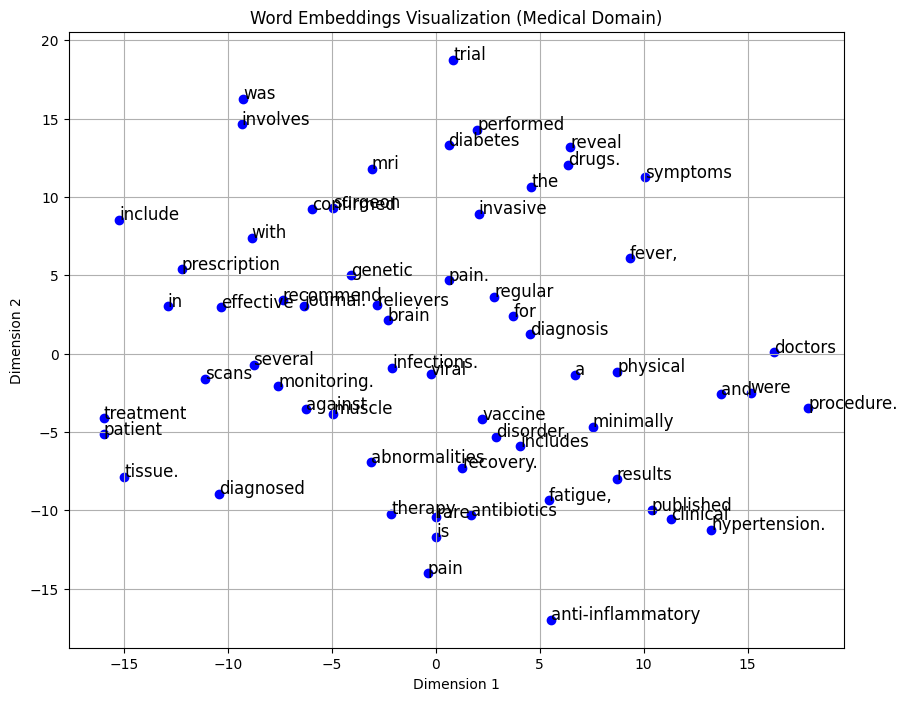

In [35]:
# Visualization of word embeddings
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], color="blue")

#0.02 is a small "nudge" used for label offsetting.If removed, text label would be pinned exactly on top of the data point
# (the dot), making both the dot and the text hard to rea

for i, word in enumerate(words):
  #plt.text(tsne_result[i, 0] + 0.02, tsne_result[i, 1] + 0.02, word, fontsize=12)
  plt.text(tsne_result[i, 0], tsne_result[i, 1], word, fontsize=12)
  print(word)
  print(i)
plt.title("Word Embeddings Visualization (Medical Domain)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

In [33]:
# Analyze domain-specific semantics
def find_similar_words(input_word, top_n=5):
  try:
    # model.wv.most_similar: finds the words in your vocabulary that are mathematically closest to your input_word in vector space.
    #it used cosine similarity to calculate the "angle" between your input_word vector and every other word vector in the model.
    similar_words = model.wv.most_similar(input_word, topn=top_n)
    print(f"Words similar to '{input_word}':")
    for word, similarity in similar_words:
            print(f" {word} ({similarity:.2f})")#.2f: format a number as a fixed-point decimal rounded to exactly two decimal places.
  except KeyError:
    print(f"'{input_word}' not found in vocabulary.")

In [ ]:
# Example: Generate semantically similar words
find_similar_words("treatment")
find_similar_words("vaccine")

find_similar_words("yogi")
find_similar_words("meditation")

Words similar to 'treatment':
 patient (0.25)
 pain. (0.14)
 brain (0.12)
 against (0.11)
 muscle (0.11)
Words similar to 'vaccine':
 disorder. (0.20)
 tissue. (0.14)
 recovery. (0.12)
 therapy (0.10)
 doctors (0.09)
'yogi' not found in vocabulary.
'meditation' not found in vocabulary.
